# Blue Owl (OWL) Financials Notebook
This notebook:
 - Loads 5Y price history (Yahoo Finance)
 - Loads 3 financial statements (Income Statement, Balance Sheet, Cash Flow)
 - Cleans the statement tables into consistent numeric format
 - Builds a comp table, calculates key ratios, and verifies statement linkage
 - Returns `statements_ok` (True/False) based on reconciliation checks

## Imports + Helpers
 Helper functions included:
 - `load_statement_xlsx`: reads a statement XLSX and returns a clean table
 - `period_to_year`: converts column headers like `DEC '25` to `2025`
 - `to_long`: converts wide statement format to long format (year/value)
 - `pick_line_item`: selects the best matching line item by regex patterns
 - `get_series`: extracts a single metric series by year (handles duplicates)
 - `align`: aligns series to shared years (intersection)
 - `safe_div`: division with zero-protection (avoids divide-by-zero)

In [1]:
# Imports modules & set funcs 
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openpyxl import load_workbook
import yfinance as yf

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

# Local path resolver: uses notebook working directory if present, otherwise /mnt/data
HERE = Path.cwd()
p = lambda name: (HERE / name) if (HERE / name).exists() 

# Period header pattern used in the statement exports
# Examples matched: "DEC '25", "DEC 2025"
PERIOD_RE = re.compile(r"^[A-Z]{3}\s'?(\d{2}|\d{4})$")

def load_statement_xlsx(path: Path, sheet: str | None = None, fillna_value: float | None = 0.0) -> pd.DataFrame:
    """
    Load a statement XLSX export where:
    - There is a header row containing period columns like "DEC '25", "DEC '24", etc.
    - The first column is a 'line_item' column
    - There may be section header rows ("Assets", "Operating Activities") that contain no numeric values

    Steps:
    1) Read the sheet with openpyxl to preserve the exact cell layout (including blank rows)
    2) Detect the header row by finding the row with the most period-like cells
    3) Build columns: ['line_item', <period columns>]
    4) Convert period columns to numeric (coerce invalid -> NaN)
    5) Drop section header rows where ALL numeric columns are NaN
    6) Optionally fill remaining NaNs in numeric cells with `fillna_value` (default 0.0)
       - This makes tables Tableau-friendly and avoids NaNs in computations

    Returns:
    Clean wide DataFrame:
    line_item | DEC '25 | DEC '24 | ...
    """
    wb = load_workbook(path, data_only=True)
    ws = wb[sheet or wb.sheetnames[0]]
    raw = pd.DataFrame(ws.values)

    # Detect header row: count how many cells match the PERIOD_RE per row
    match_counts = raw.apply(lambda r: r.astype(str).str.match(PERIOD_RE).sum(), axis=1)
    header_i = int(match_counts.idxmax())
    header = raw.loc[header_i].tolist()

    # Collect non-empty period columns from the header row
    period_cols = []
    for x in header[1:]:
        if x is None:
            continue
        x = str(x).strip()
        if x:
            period_cols.append(x)

    # Slice the table under the header row
    cols = ["line_item"] + period_cols
    out = raw.loc[header_i + 1 :, : len(cols) - 1].copy()
    out.columns = cols

    # Remove completely empty rows
    out = out.dropna(how="all")

    # Keep only rows that have a line_item
    out = out[out["line_item"].notna()]
    out["line_item"] = out["line_item"].astype(str).str.strip()
    out = out[out["line_item"].ne("")]

    # Convert period columns to numeric
    num_cols = cols[1:]
    out[num_cols] = out[num_cols].apply(pd.to_numeric, errors="coerce")

    # Drop section headers / spacers: rows where ALL numeric columns are NaN
    out = out[~out[num_cols].isna().all(axis=1)].copy()

    # Optional: fill remaining NaNs in numeric columns (common when a metric isn't reported in older years)
    if fillna_value is not None:
        out[num_cols] = out[num_cols].fillna(fillna_value)

    return out.reset_index(drop=True)


def period_to_year(col: str) -> int | None:
    """
    Convert a period column label into a numeric year.
    Supported formats:
    - "DEC '25" -> 2025
    - "DEC 2025" -> 2025

    Returns:
    - int year if pattern matches
    - None otherwise
    """
    if col is None:
        return None
    s = str(col).strip().upper()
    m = re.match(r"^[A-Z]{3}\s'?(\d{2}|\d{4})$", s)
    if not m:
        return None
    y = m.group(1)
    return (2000 + int(y)) if len(y) == 2 else int(y)


def to_long(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert a wide-format statement into long format.

    Input:
    line_item | DEC '25 | DEC '24 | ...
    Output:
    year | line_item | line_item_norm | value

    Notes:
    - 'line_item_norm' is a normalized version of the line item for robust regex matching
      (lowercase, alphanumeric tokens, collapsed whitespace)
    """
    # Identify period columns that can be mapped into years
    year_cols = [c for c in df.columns if c != "line_item" and period_to_year(c) is not None]

    # Melt into long format
    out = df[["line_item"] + year_cols].melt(id_vars="line_item", var_name="period", value_name="value")

    # Add numeric year, drop invalid period rows
    out["year"] = out["period"].map(period_to_year)
    out = out.dropna(subset=["year"]).drop(columns=["period"])

    # Normalize line item text for regex matching
    out["line_item"] = out["line_item"].astype(str).str.strip()
    out["line_item_norm"] = (
        out["line_item"].str.lower()
        .str.replace(r"[^a-z0-9]+", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    # Ensure numeric values
    out["value"] = pd.to_numeric(out["value"], errors="coerce")
    return out.sort_values(["line_item_norm", "year"]).reset_index(drop=True)


def pick_line_item(long_df: pd.DataFrame, patterns: list[str]) -> str | None:
    """
    Pick the best matching original line_item label from a long-format statement.

    Strategy:
    - Check patterns in priority order (first match wins)
    - Find all candidate line items whose normalized text matches the pattern
    - Choose the shortest normalized label (usually the cleanest 'total' row vs verbose duplicates)

    Returns:
    - The original 'line_item' string if found
    - None if no pattern matches
    """
    s = long_df["line_item_norm"]
    for pat in patterns:
        mask = s.str.contains(pat, regex=True, na=False)
        if mask.any():
            candidates = long_df.loc[mask, ["line_item", "line_item_norm"]].drop_duplicates()
            idx = candidates["line_item_norm"].str.len().idxmin()
            return candidates.loc[idx, "line_item"]
    return None


def get_series(long_df: pd.DataFrame, patterns: list[str]) -> tuple[pd.Series | None, str | None]:
    """
    Extract a year-indexed numeric Series for a given metric using regex patterns.

    Why duplicates happen:
    - Some exports include the same metric multiple times (e.g., subtotal and repeated line)
    - This can create duplicate (year) entries when slicing by line_item

    Fix:
    - Collapse duplicates by year using max() (safe default for repeated identical values)

    Returns:
    - (Series indexed by year, matched line_item label)
    - (None, None) if no line item matches
    """
    li = pick_line_item(long_df, patterns)
    if li is None:
        return None, None
    tmp = long_df.loc[long_df["line_item"] == li, ["year", "value"]].copy()
    s = tmp.groupby("year")["value"].max().sort_index()
    return s, li


def align(*series_list: pd.Series) -> list[pd.Series]:
    """
    Align multiple Series to a shared set of years.

    - Uses intersection of available year indices
    - Returns reindexed series in the original input order
    - If no overlapping years exist, returns a list of None entries
    """
    years = None
    for s in series_list:
        if s is None:
            continue
        years = set(s.index) if years is None else years.intersection(set(s.index))
    if not years:
        return [None for _ in series_list]
    years = sorted(years)
    return [s.reindex(years) if s is not None else None for s in series_list]


def safe_div(a: pd.Series, b: pd.Series) -> pd.Series:
    """
    Safe division helper:
    - Replaces 0 denominators with NaN to avoid inf / errors
    """
    return a / b.replace(0, np.nan)

## Plotting Blue Owl
Pulls 5 years of OWL price history from Yahoo Finance and plots the adjusted close (or close if unavailable).

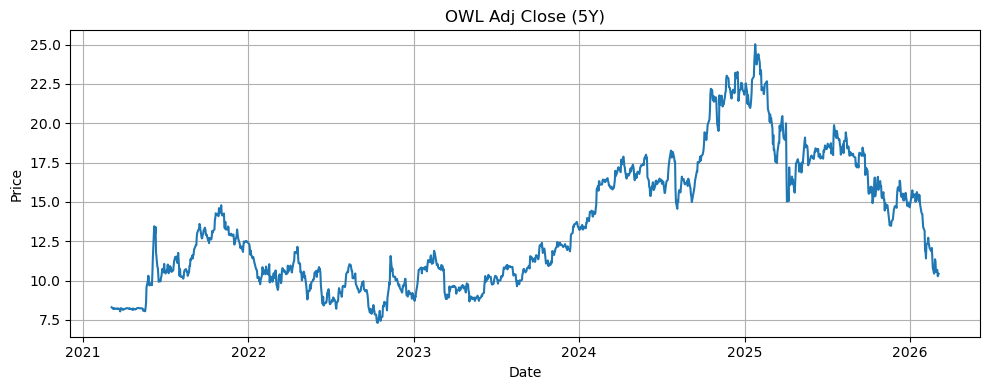

Price,Date,Adj Close,Close,High,Low,Open,Volume
Ticker,,OWL,OWL,OWL,OWL,OWL,OWL
0,2021-03-05,8.299774,10.06,10.155,9.960,9.98,819400
1,2021-03-08,8.209019,9.95,10.100,9.945,10.06,240700
2,2021-03-09,8.225522,9.97,10.050,9.950,9.98,247600
3,2021-03-10,8.192520,9.93,10.000,9.920,9.97,383000
4,2021-03-11,8.233771,9.98,10.000,9.900,9.95,770500


In [3]:
# Stock Price (5Y)
ticker = "OWL"
price = yf.download(ticker, period="5y", auto_adjust=False, progress=False).reset_index()
close_col = "Adj Close" if "Adj Close" in price.columns else "Close"

plt.figure(figsize=(10, 4))
plt.plot(price["Date"], price[close_col])
plt.title(f"{ticker} {close_col} (5Y)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.tight_layout()
plt.show()

price.head()

## Load Statements (XLSX)
Loads Income Statement, Balance Sheet, and Cash Flow from local XLSX exports using `load_statement_xlsx`.

In [5]:
# Load statements (XLSX) ===
income_df = load_statement_xlsx(p("Blue Owl Net Income.xlsx"))
balance_df = load_statement_xlsx(p("Blue Owl Balance Sheet.xlsx"))
cashflow_df = load_statement_xlsx(p("Blue Owl Cash Flow.xlsx"))

display(income_df.head())
display(balance_df.head())
display(cashflow_df.head())

,line_item,DEC '25,DEC '24,DEC '23,DEC '22,DEC '21,DEC '20
0,Sales,2870.178,2295.427,1731.608,1369.722,823.878,249.815
1,Cost of Goods Sold (COGS) incl. D&A,382.398,274.916,310.567,272.196,116.528,0.673
2,Depreciation & Amortization Expense,382.398,274.916,310.567,272.196,116.528,0.673
3,Depreciation,23.446,16.660,10.226,15.287,2.639,0.673
4,Amortization of Intangibles,358.952,258.256,300.341,256.909,113.889,0.000


,line_item,DEC '25,DEC '24,DEC '23,DEC '22,DEC '21,DEC '20
0,Cash & Short-Term Investments,194.512,152.089,104.160,68.079,42.567,11.630
1,Cash Only,194.512,152.089,104.160,68.079,42.567,11.630
2,Short-Term Receivables,694.056,548.730,367.136,357.921,224.576,92.698
3,Total Current Assets,888.568,700.819,471.296,426.000,267.143,104.328
4,"Net Property, Plant & Equipment",675.145,512.839,416.562,295.601,93.984,3.356


,line_item,DEC '25,DEC '24,DEC '23,DEC '22,DEC '21,DEC '20
0,Net Income / Starting Line,305.487,420.446,220.776,-40.235,-1802.266,-82.441
1,"Depreciation, Depletion & Amortization",382.398,274.916,310.567,272.196,116.528,0.673
2,Depreciation and Depletion,23.446,16.660,10.226,15.287,2.639,0.673
3,Amortization of Intangible Assets,358.952,258.256,300.341,256.909,113.889,0.000
4,Deferred Taxes & Investment Tax Credit,21.204,26.756,4.204,-23.947,-66.138,-0.475



## Comp Table + Ratios + Statement Checks
 This cell:
 - Converts statements to long format for matching and extraction
 - Extracts key metrics (Revenue, Net Income, CFO, etc.)
 - Computes Free Cash Flow (FCF) from CFO and CapEx (sign-safe)
 - Runs reconciliation checks:
   - Balance sheet: Assets ≈ Liabilities + Equity
   - Cash flow: CFO + CFI + CFF ≈ Net change in cash
   - Net income: IS net income ≈ CFS starting line net income
   - Cash roll-forward: Cash(BS) ≈ Prior Cash(BS) + Net Change in Cash
 - Builds a comp table (key lines + YoY growth)
 - Computes ratios (margins, leverage, ROA, coverage, cash margins)
 - Sets and returns `statements_ok` (True/False)

In [7]:
# Comp table + ratios + statement checks 
income_long = to_long(income_df)
balance_long = to_long(balance_df)
cashflow_long = to_long(cashflow_df)

# Map extracted metric names -> matched line item labels (for auditability)
maps = {}

# ----- Income statement pulls -----
rev, maps["Revenue"] = get_series(income_long, [r"^(sales|revenue|total revenue)s?$"])
gross, maps["Gross Profit"] = get_series(income_long, [r"gross (income|profit)"])
ebit, maps["EBIT"] = get_series(income_long, [r"\bebit\b", r"operating income"])
da, maps["D&A"] = get_series(income_long, [r"depreciation.*amortization expense", r"depreciation.*amortization"])
int_exp, maps["Interest Expense"] = get_series(income_long, [r"interest expense"])
# Prefer "consolidated net income" so it ties to cash flow's net income starting line
ni_is, maps["Net Income (IS)"] = get_series(income_long, [r"consolidated net income", r"\bnet income\b"])

# ----- Balance sheet pulls -----
ta, maps["Total Assets"] = get_series(balance_long, [r"total assets"])
tle, maps["Total Liab & Eq"] = get_series(balance_long, [r"total liabilities.*equity"])
tl, maps["Total Liabilities"] = get_series(balance_long, [r"total liabilities(?!.*equity)"])
te, maps["Total Equity"] = get_series(balance_long, [r"total shareholders'? equity", r"total equity"])
cash_bs, maps["Cash (BS)"] = get_series(balance_long, [
    r"cash\s*&\s*short term investments",
    r"cash\s*&\s*short-term investments",
    r"cash and cash equivalents",
    r"^cash only$",
    r"^cash$",
])

# ----- Cash flow pulls -----
ni_cf, maps["Net Income (CFS)"] = get_series(cashflow_long, [r"net income\s*/\s*starting line", r"\bnet income\b"])
cfo, maps["CFO"] = get_series(cashflow_long, [r"net operating cash flow", r"net cash.*operating"])
cfi, maps["CFI"] = get_series(cashflow_long, [r"net investing cash flow", r"net cash.*investing"])
cff, maps["CFF"] = get_series(cashflow_long, [r"net financing cash flow", r"net cash.*financing"])
netchg, maps["Net Change in Cash"] = get_series(cashflow_long, [r"net change in cash", r"increase.*cash", r"decrease.*cash"])
capex, maps["CapEx"] = get_series(cashflow_long, [
    r"capital expenditures",
    r"purchase of property plant and equipment",
    r"purchase of property plant equipment",
    r"investments in property plant and equipment",
    r"additions to property plant and equipment",
    r"\bcapex\b",
])

print("=== Matched line items ===")
for k, v in maps.items():
    print(f"{k:18s}: {v}")

# ----- Free Cash Flow (FCF) -----
# Convention:
# - Many statements report CapEx as a negative cash outflow (e.g., -100)
# - If CapEx is negative, CFO + CapEx is correct
# - If CapEx is positive, CFO - CapEx is correct
fcf = None
if (cfo is not None) and (capex is not None):
    o, cx = align(cfo, capex)
    fcf = pd.Series(np.where(cx <= 0, o + cx, o - cx), index=o.index, name="FCF")
else:
    print("\n[FCF] Missing CFO or CapEx match; FCF not computed.")

# ----- Statement checks -----
TOL = 1e-3  # tolerance for reconciliation (adjust if your data are scaled/rounded)
checks = {}

# Balance Sheet: Assets ≈ Liabilities + Equity
if (ta is not None) and (tle is not None):
    a, b = align(ta, tle)
    checks["BS: Assets-(L+E)"] = a - b
elif (ta is not None) and (tl is not None) and (te is not None):
    a, l, e = align(ta, tl, te)
    checks["BS: Assets-(L+E)"] = a - (l + e)

# Cash Flow: CFO + CFI + CFF ≈ Net change in cash
if (cfo is not None) and (cfi is not None) and (cff is not None) and (netchg is not None):
    o, i, f, n = align(cfo, cfi, cff, netchg)
    checks["CFS: (CFO+CFI+CFF)-NetChg"] = (o + i + f) - n

# Link: Net income ties IS to CFS starting line
if (ni_is is not None) and (ni_cf is not None):
    a, b = align(ni_is, ni_cf)
    checks["LINK: NI(IS)-NI(CFS)"] = a - b

# Link: Cash roll-forward using Balance Sheet cash and CFS net change
# Ignore the first year (no prior cash available)
if (cash_bs is not None) and (netchg is not None):
    c, n = align(cash_bs, netchg)
    checks["LINK: Cash(BS)-(PriorCash+NetChg)"] = c - (c.shift(1) + n)

# Check table and boolean result
chk_df = pd.DataFrame(checks).sort_index()
chk_df.index.name = "year"
print("\n=== Statement linkage checks (differences should be ~0) ===")
display(chk_df)

chk_abs = chk_df.abs()
if "LINK: Cash(BS)-(PriorCash+NetChg)" in chk_abs.columns and len(chk_abs.index) > 0:
    chk_abs.loc[chk_abs.index.min(), "LINK: Cash(BS)-(PriorCash+NetChg)"] = 0.0

statements_ok = bool((chk_abs <= TOL).all().all())
summary = pd.DataFrame({"max_abs_diff": chk_abs.max(axis=1), "all_pass": (chk_abs <= TOL).all(axis=1)})
print("\n=== Pass/Fail by year ===")
display(summary)
print("\nSTATEMENTS BALANCE:", statements_ok)

# ----- Comp table -----
# Key metrics + YoY growth for quick review and Tableau export
comp = pd.DataFrame(index=sorted(set(rev.index) if rev is not None else []))
comp.index.name = "year"

def add_col(name, s):
    comp[name] = np.nan if s is None else s.reindex(comp.index)

add_col("Revenue", rev)
add_col("Gross Profit", gross)
add_col("EBIT", ebit)
add_col("Net Income (Consolidated)", ni_is)
add_col("CFO", cfo)
add_col("CapEx", capex)
if fcf is not None:
    add_col("FCF", fcf)
add_col("Cash (BS)", cash_bs)
add_col("Total Assets", ta)
add_col("Total Liabilities", tl)
add_col("Total Equity", te)

for col in ["Revenue", "Net Income (Consolidated)", "CFO", "FCF"]:
    if col in comp.columns:
        comp[col + " YoY %"] = comp[col].pct_change() * 100

print("\n=== Comp Table ===")
display(comp)

# ----- Ratios -----
ratios = pd.DataFrame(index=comp.index)
ratios.index.name = "year"

if (rev is not None) and (gross is not None):
    g, r = align(gross, rev)
    ratios["Gross Margin"] = safe_div(g, r)

if (rev is not None) and (ebit is not None):
    e, r = align(ebit, rev)
    ratios["EBIT Margin"] = safe_div(e, r)

if (rev is not None) and (ni_is is not None):
    n, r = align(ni_is, rev)
    ratios["Net Margin"] = safe_div(n, r)

# EBITDA = EBIT + D&A
if (ebit is not None) and (da is not None):
    e, d = align(ebit, da)
    ebitda = e + d
    ratios["EBITDA"] = ebitda
    if rev is not None:
        ed, r = align(ebitda, rev)
        ratios["EBITDA Margin"] = safe_div(ed, r)

# Interest coverage
if (ebit is not None) and (int_exp is not None):
    e, ie = align(ebit, int_exp)
    ratios["Interest Coverage (EBIT/IntExp)"] = safe_div(e, ie)

# ROA = Net Income / Avg Assets
if (ni_is is not None) and (ta is not None):
    n, a = align(ni_is, ta)
    avg_a = (a + a.shift(1)) / 2
    avg_a.iloc[0] = a.iloc[0]
    ratios["ROA (NI/Avg Assets)"] = safe_div(n, avg_a)

# Liquidity: current ratio (if available)
tca, _ = get_series(balance_long, [r"total current assets"])
tcl, _ = get_series(balance_long, [r"total current liabilities"])
if (tca is not None) and (tcl is not None):
    ca, cl = align(tca, tcl)
    ratios["Current Ratio"] = safe_div(ca, cl)

# Leverage: total liabilities / equity
if (tl is not None) and (te is not None):
    l, e = align(tl, te)
    ratios["Leverage (Liab/Equity)"] = safe_div(l, e)

# Cash efficiency
if (cfo is not None) and (rev is not None):
    o, r = align(cfo, rev)
    ratios["CFO Margin"] = safe_div(o, r)

if (fcf is not None) and (rev is not None):
    f, r = align(fcf, rev)
    ratios["FCF Margin"] = safe_div(f, r)

print("\n=== Ratios ===")
display(ratios)

statements_ok

=== Matched line items ===
Revenue           : Sales
Gross Profit      : Gross Income
EBIT              : EBIT
D&A               : Depreciation & Amortization Expense
Interest Expense  : Interest Expense
Net Income (IS)   : Consolidated Net Income
Total Assets      : Total Assets
Total Liab & Eq   : Total Liabilities & Shareholders' Equity
Total Liabilities : Total Liabilities
Total Equity      : Total Shareholders' Equity
Cash (BS)         : Cash Only
Net Income (CFS)  : Net Income / Starting Line
CFO               : Net Operating Cash Flow
CFI               : Net Investing Cash Flow
CFF               : Net Financing Cash Flow
Net Change in Cash: Net Change in Cash
CapEx             : Capital Expenditures

=== Statement linkage checks (differences should be ~0) ===


C:\Users\chris\AppData\Local\Temp\ipykernel_1960\4160691704.py:90: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = s.str.contains(pat, regex=True, na=False)
C:\Users\chris\AppData\Local\Temp\ipykernel_1960\4160691704.py:90: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = s.str.contains(pat, regex=True, na=False)


,BS: Assets-(L+E),CFS: (CFO+CFI+CFF)-NetChg,LINK: NI(IS)-NI(CFS),LINK: Cash(BS)-(PriorCash+NetChg)
year,,,,
2020,0.0,0.000000e+00,0.0,NaN
2021,0.0,-1.030287e-13,0.0,0.000000e+00
2022,0.0,0.000000e+00,0.0,-1.421085e-14
2023,0.0,1.421085e-14,0.0,0.000000e+00
2024,0.0,-8.526513e-14,0.0,0.000000e+00
2025,0.0,-1.136868e-13,0.0,0.000000e+00



=== Pass/Fail by year ===


,max_abs_diff,all_pass
year,,
2020,0.000000e+00,True
2021,1.030287e-13,True
2022,1.421085e-14,True
2023,1.421085e-14,True
2024,8.526513e-14,True
2025,1.136868e-13,True



STATEMENTS BALANCE: True

=== Comp Table ===


,Revenue,Gross Profit,EBIT,Net Income (Consolidated),CFO,CapEx,FCF,Cash (BS),Total Assets,Total Liabilities,Total Equity,Revenue YoY %,Net Income (Consolidated) YoY %,CFO YoY %,FCF YoY %
year,,,,,,,,,,,,,,,
2020,249.815,249.142,-58.727,-82.441,5.234,-0.652,4.582,11.630,121.597,622.758,-507.687,NaN,NaN,NaN,NaN
2021,823.878,707.350,-824.849,-1802.266,281.658,-5.261,276.397,42.567,8266.398,2418.828,1663.567,229.795248,2086.128261,5281.314482,5932.234832
2022,1369.722,1097.526,10.306,-40.235,728.447,-65.539,662.908,68.079,8893.075,3344.189,1604.698,66.253013,-97.767533,158.628194,139.839072
2023,1731.608,1421.041,331.124,220.776,949.145,-67.905,881.240,104.160,8817.621,3539.690,1528.239,26.420398,-648.716292,30.297057,32.935490
2024,2295.427,2020.511,681.233,420.446,999.555,-64.187,935.368,152.089,10992.470,5186.434,2127.758,32.560429,90.440084,5.311096,6.142254
2025,2870.178,2487.780,493.213,305.487,1256.032,-57.748,1198.284,194.512,12467.684,6413.485,2205.362,25.038958,-27.342156,25.659118,28.108295



=== Ratios ===


,Gross Margin,EBIT Margin,Net Margin,EBITDA,EBITDA Margin,Interest Coverage (EBIT/IntExp),ROA (NI/Avg Assets),Current Ratio,Leverage (Liab/Equity),CFO Margin,FCF Margin
year,,,,,,,,,,,
2020,0.997306,-0.235082,-0.330008,-58.054,-0.232388,-2.465863,-0.677985,0.391663,-1.226657,0.020952,0.018342
2021,0.858562,-1.001179,-2.187540,-708.321,-0.859740,-30.241943,-0.429725,1.192896,1.454001,0.341869,0.335483
2022,0.801276,0.007524,-0.029375,282.502,0.206248,0.184990,-0.004690,0.976610,2.083999,0.531821,0.483973
2023,0.820648,0.191223,0.127498,641.691,0.370575,4.374392,0.024931,0.925053,2.316189,0.548129,0.508914
2024,0.880233,0.296778,0.183167,956.149,0.416545,5.588733,0.042448,1.187875,2.437511,0.435455,0.407492
2025,0.866769,0.171841,0.106435,875.611,0.305072,3.011896,0.026043,1.290492,2.908133,0.437615,0.417495


True

## Revenue vs Net Income
Line chart comparing Revenue and Consolidated Net Income by year.

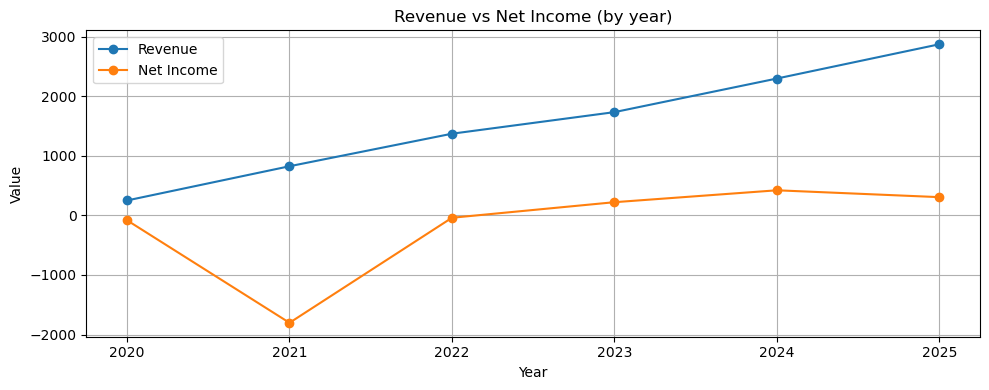

In [9]:
# Revenue vs Net Income chart 
plt.figure(figsize=(10, 4))
plt.plot(comp.index, comp["Revenue"], marker="o", label="Revenue")
plt.plot(comp.index, comp["Net Income (Consolidated)"], marker="o", label="Net Income")
plt.title("Revenue vs Net Income (by year)")
plt.xlabel("Year")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Free Cash Flow (FCF) by Year
Bar chart of Free Cash Flow computed from:
 - `FCF = CFO + CapEx` when CapEx is negative (cash outflow)
 - `FCF = CFO - CapEx` when CapEx is positive

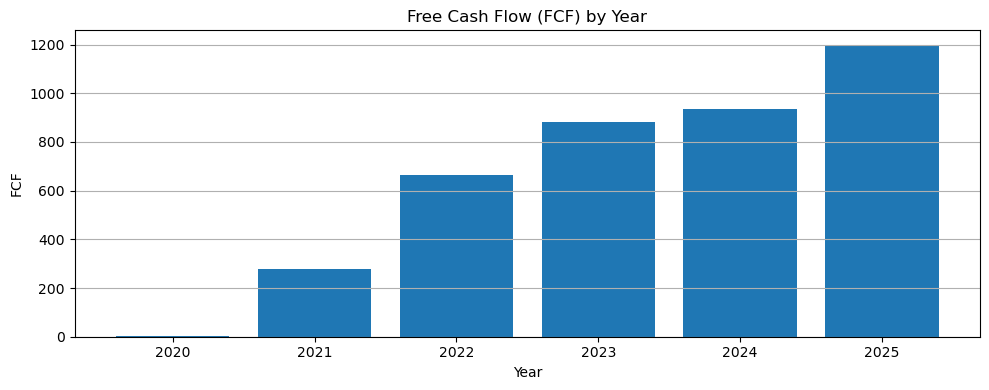

In [11]:
# Free Cash Flow by Year chart
if "FCF" in comp.columns and comp["FCF"].notna().any():
    plt.figure(figsize=(10, 4))
    plt.bar(comp.index, comp["FCF"])
    plt.title("Free Cash Flow (FCF) by Year")
    plt.xlabel("Year")
    plt.ylabel("FCF")
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()
else:
    print("FCF not available (missing CapEx or CFO match). Check matched CapEx line.")

## Export
Save new excel files

In [25]:
#  Save Tableau-ready Excel files (same folder as notebook) 
price_out = Path(f"{ticker}_price_5y.xlsx")
fin_out   = Path(f"{ticker}_financial_statements.xlsx")

# Stock price file ---
price_to_save = price.copy()

# Flatten columns if yfinance returns MultiIndex (safe guard)
if isinstance(price_to_save.columns, pd.MultiIndex):
    price_to_save.columns = [
        " ".join([str(x) for x in tup if x and str(x) != ""]).strip()
        for tup in price_to_save.columns.to_list()
    ]

with pd.ExcelWriter(price_out, engine="openpyxl") as w:
    price_to_save.to_excel(w, sheet_name="price_daily", index=False)

# Financial statements file (3 statements + long format for Tableau) ---
income_long_ = to_long(income_df)
income_long_.insert(0, "statement", "Income")

balance_long_ = to_long(balance_df)
balance_long_.insert(0, "statement", "Balance")

cashflow_long_ = to_long(cashflow_df)
cashflow_long_.insert(0, "statement", "CashFlow")

financials_long = pd.concat([income_long_, balance_long_, cashflow_long_], ignore_index=True)

with pd.ExcelWriter(fin_out, engine="openpyxl") as w:
    income_df.to_excel(w, sheet_name="income_wide", index=False)
    balance_df.to_excel(w, sheet_name="balance_wide", index=False)
    cashflow_df.to_excel(w, sheet_name="cashflow_wide", index=False)
    financials_long.to_excel(w, sheet_name="financials_long", index=False)

    # optional outputs for Tableau / audit
    if "comp" in globals():
        comp.reset_index().to_excel(w, sheet_name="comp_table", index=False)
    if "ratios" in globals():
        ratios.reset_index().to_excel(w, sheet_name="ratios", index=False)
    if "chk_df" in globals():
        chk_df.reset_index().to_excel(w, sheet_name="checks", index=False)

print("Saved:", price_out.resolve())
print("Saved:", fin_out.resolve())

Saved: C:\Users\chris\Blue Owl Overview\OWL_price_5y.xlsx
Saved: C:\Users\chris\Blue Owl Overview\OWL_financial_statements.xlsx
